# Statistics Foundations

## 6. Testing


## Test statistics

In the (not so distant) past, fast computer simulations were not accessible.

Hypothesis tests had to be based on precomputed tables of p-values for known distributions. But not every situation corresponds directly to a random variable that is easy to describe.



Because there are some situations that are commonly encountered, statisticians developed *test statistics*:

* Calculated directly from the observed quantities (i.e. they are statistics).
* Under certain assumptions, can be assumed to follow a specified probability distribution.
* Form the basis of a named standard hypothesis test.



As long as the situation correctly fits the assumptions of the test, we can follow the hypothesis testing procedure previously described. 

The p-value is now based on the test statistic (and its probability distribution under $H_0$), not the directly observed value.

## Student's t-test

The *independent samples t-test* is used to test for significant differences in the mean values of a variable that has been measured for two sub-populations.


The test statistic is

$$ t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \cdot \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}  $$

where

$$ s_p = \sqrt{\frac{(n_1 - 1)s_{1}^2 + (n_2 - 1)s_{2}^2}{n_1 + n_2-2}} $$

is the *pooled standard deviation* of the two samples.

The assumptions for this test are:



* Each sample is [independent and identically distributed](https://en.wikipedia.org/wiki/Independent_and_identically_distributed_random_variables).



* The sample means $\bar{x}_1$ and $\bar{x}_2$ should behave as if drawn from normal distributions. This is always true if the variables $X_{1}$ and $X_{2}$ are themselves normally distributed, but is also true for other distributions as long as the sample sizes are large enough (via the central limit theorem).



* The two distributions have the same variance. (There is another version of the t-test that does not require this assumption, known as [Welch's t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test)).

IF

the assumptions of the test are satisfied



AND

the null hypothesis $H_{0}$ is true



THEN

the t statistic behaves as if it is sampled from a *Student's t-distribution*. 



This distribution has a single parameter known as the *degrees of freedom*, which would be equal to $n_{1} + n_{2} - 1$.


In [212]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

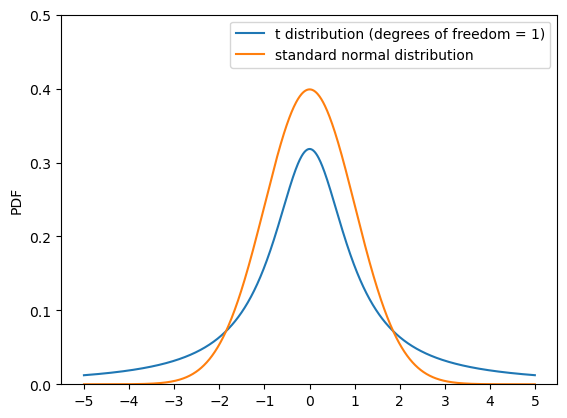

In [213]:
x = np.arange(-5,5,0.01)
t_x = stats.t.pdf(x,1)
n_x = stats.norm.pdf(x)
plt.plot(x,t_x,label = "t distribution (degrees of freedom = 1)")
plt.plot(x,n_x,label = "standard normal distribution")
plt.ylabel("PDF")
plt.legend()
plt.ylim(0,0.5)
plt.xticks(range(-5,6))
plt.show()

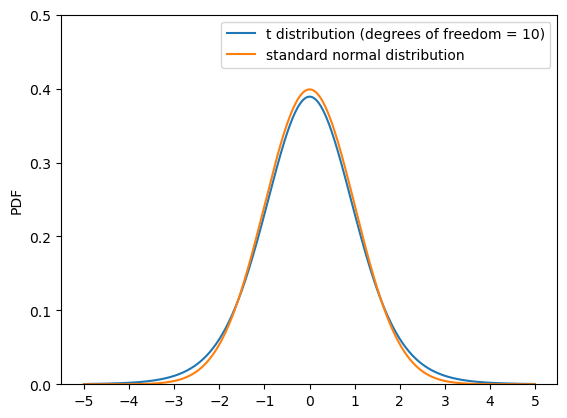

In [214]:
x = np.arange(-5,5,0.01)
t_x = stats.t.pdf(x,10)
n_x = stats.norm.pdf(x)
plt.plot(x,t_x,label = "t distribution (degrees of freedom = 10)")
plt.plot(x,n_x,label = "standard normal distribution")
plt.ylabel("PDF")
plt.legend()
plt.ylim(0,0.5)
plt.xticks(range(-5,6))
plt.show()

## Student's t-test: example



*Do the Adelie populations on Dream and Torgersen differ significantly in their body mass?*



$H_{0}$: There is no difference between the mean body mass of the two sub-populations.

$\alpha = 0.05$


In [215]:
import pandas as pd

penguins = pd.read_csv("data/penguins.csv")
adelie = penguins[ penguins['species'] == "Adelie" ]
adelie_dream = adelie[ adelie['island'] == "Dream" ]
adelie_torgersen = adelie[ adelie['island'] == "Torgersen" ]


In [216]:
n1 = len(adelie_dream['body_mass_g'].dropna())

In [217]:
xbar1 = adelie_dream['body_mass_g'].dropna().mean()

In [218]:
s1 = adelie_dream['body_mass_g'].dropna().std()

In [219]:
n2 = len(adelie_torgersen['body_mass_g'].dropna())

In [220]:
xbar2 = adelie_torgersen['body_mass_g'].dropna().mean()

In [221]:
s2 = adelie_torgersen['body_mass_g'].dropna().std()

Calculate the t-statistic using the observed data.



Adelie penguins on Dream have body mass statistics 
* $\bar{x}_1$ = 3688 g
* $s_1$ = 455.1 g
* $n_1$ = 56

Adelie penguins on Torgersen have body mass statistics 
* $\bar{x}_2$ = 3706 g
* $s_2$ = 445.1 g
* $n_2$ = 51

In [222]:
sp = np.sqrt( ((n1 - 1)*(s1 ** 2) + (n2 - 1)*(s2 ** 2)) / (n1 + n2 - 2) )
t_obs = (xbar1 - xbar2) / (sp * np.sqrt(1/n1 + 1/n2))

$t$ = -0.20624



The t-distribution of interest has degrees of freedom $n1 + n2 - 1$ = 106

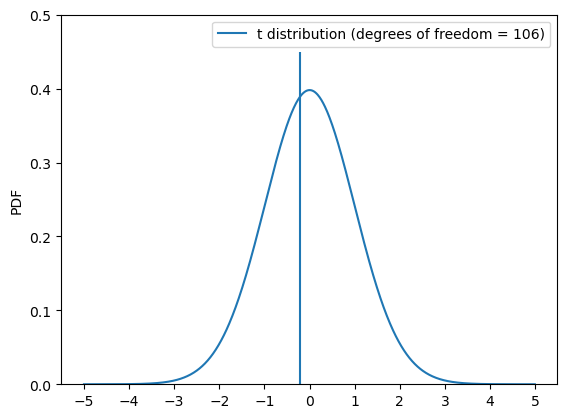

In [223]:
x = np.arange(-5,5,0.01)
t_x = stats.t.pdf(x,106)
plt.plot(x,t_x,label = "t distribution (degrees of freedom = 106)")
plt.vlines(t_obs,0,0.45)
plt.ylabel("PDF")
plt.legend()
plt.ylim(0,0.5)
plt.xticks(range(-5,6))
plt.show()

What does "as extreme or more extreme" mean in this case?



Clearly, values of $t$ less than -0.20624 are "more extreme".



But also, the t statistic is based on the difference between the two means, which could be positive or negative.



Because we did not *a priori* have a belief about which population would have bigger body mass, we should also consider the values $t$ > +0.20624 as possible results that are "more extreme" than the observed difference.

This situation is known as a *two-tailed test*, where deviations of the test statistic in either direction (both the upper and lower tails) are considered relevant to our original question.

In a two-tailed test, we *double* the p-value associated with the tail that contains our observed value - in this case, the lower tail. 

This procedure also works with test statistics having asymmetrical probability distributions.

```
pval = stats.t.cdf(t_obs, 106) * 2
print("p =", pval)
```

In [224]:
pval = stats.t.cdf(t_obs, 106) * 2
print("p =", pval)

p = 0.8369976258647323


So p > $\alpha$ and we do not reject the null hypothesis

In practice, we can perform hypothesis tests much more easily using python functions that accept our data and perform all of the necessary calculations.

```
from scipy.stats import ttest_ind
result = ttest_ind(adelie_dream['body_mass_g'], 
                   adelie_torgersen['body_mass_g'], 
                   nan_policy='omit',
                   alternative="two-sided")
print("observed t =", result.statistic)
print("p-value =", result.pvalue)
```

In [225]:
from scipy.stats import ttest_ind
result = ttest_ind(adelie_dream['body_mass_g'], 
                   adelie_torgersen['body_mass_g'], 
                   nan_policy='omit',
                   alternative="two-sided")
print("observed t =", result.statistic)
print("p-value =", result.pvalue)


observed t = -0.20624183279962707
p-value = 0.8370013888792112


## Chi-square test

As another example of a hypothesis test, we will look at the *chi-square test for independence*.

This test is used to assess whether two categorical variables are independent of each other, by comparing observed frequencies to their expectations under $H_0$ (i.e. independence of the two variables).


The test statistic is

$$ X^2=\sum^k_{i=1}{\frac{(x_i-m_i)^2}{m_i}} $$

where

$x_i$ are the observed frequencies for each of $k$ outcomes

$m_i$ are the expected frequencies under $H_0$

$m_i = np_i$, where $p_i$ are the probabilities for each possible outcome.

Under the null hypothesis, $X^2$ behaves as if sampled from a $\chi^2$ distribution

The degrees of freedom for this distribution = the number of *independent* frequencies.

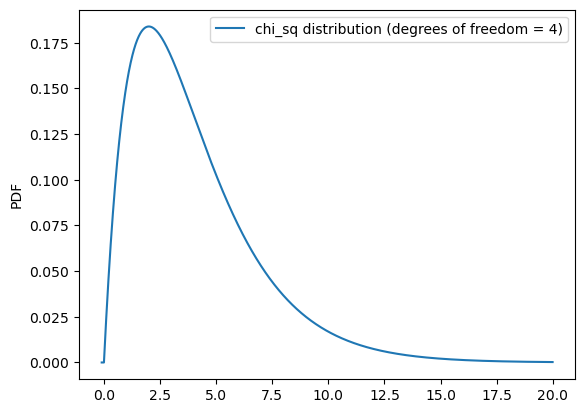

In [226]:
x = np.arange(-0.1,20,0.01)
chisq_x = stats.chi2.pdf(x,df=4)
plt.plot(x,chisq_x,label = "chi_sq distribution (degrees of freedom = 4)")
plt.ylabel("PDF")
plt.legend()
#plt.ylim(0,0.5)
#plt.xticks(range(0,6))
plt.show()



## Chi-square test: example

*Is the sex ratio of all three penguin species the same?*

$H_0$: sex is independent of species

$\alpha$ = 0.05

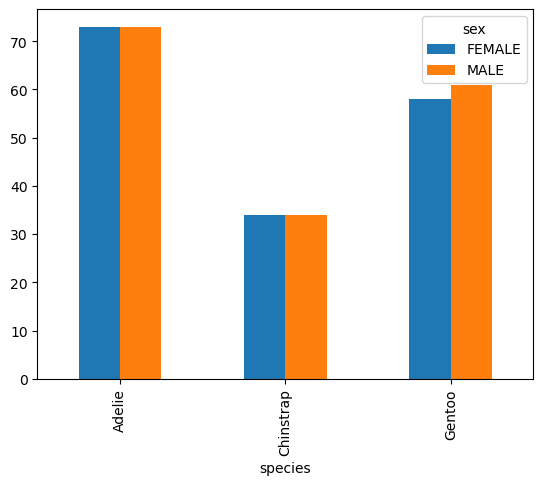

In [227]:
pd.crosstab(penguins['species'], columns=penguins['sex']) \
    .plot.bar()
plt.show()

In [228]:
print('observed frequencies:')
observed = pd.crosstab(penguins['species'], columns=penguins['sex'])
observed

observed frequencies:


sex,FEMALE,MALE
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


In [229]:
totals_sex = pd.crosstab(penguins['species'], columns=penguins['sex']).sum(axis=0)
totals_sex

sex
FEMALE    165
MALE      168
dtype: int64

In [230]:
totals_species = pd.crosstab(penguins['species'], columns=penguins['sex']).sum(axis=1)
totals_species

species
Adelie       146
Chinstrap     68
Gentoo       119
dtype: int64

In [231]:
print('expected frequencies:')
expected = pd.DataFrame([totals_species[x]/totals_sex.sum() * totals_sex for x in totals_species.index], 
             index=totals_species.index)
expected

expected frequencies:


sex,FEMALE,MALE
species,,
Adelie,72.342342,73.657658
Chinstrap,33.693694,34.306306
Gentoo,58.963964,60.036036


In [232]:
chisq_obs = ((observed - expected)**2 / expected).sum().sum()
print( "chisq_obs =", chisq_obs )

chisq_obs = 0.04860717014078318


Degrees of freedom for a contingency table = (number of columns - 1) * (number of rows - 1)

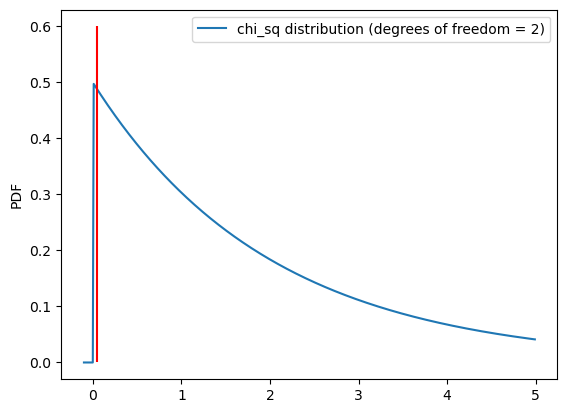

In [233]:
x = np.arange(-0.1,5,0.01)
chisq_x = stats.chi2.pdf(x,df=2)
plt.plot(x,chisq_x,label = "chi_sq distribution (degrees of freedom = 2)")
plt.ylabel("PDF")
plt.vlines(chisq_obs, 0, 0.6, color='red')
plt.legend()
plt.show()

"As extreme or more extreme" in this case refers only to the *upper tail*.

```
pval = 1 - stats.chi2.cdf(chisq_obs, 2)
print("pval =", pval)
```

In [234]:
pval = 1 - stats.chi2.cdf(chisq_obs, 2)
print("p =", pval)

p = 0.9759893689765846


Clearly p > $\alpha$ and we do not reject the null hypothesis.

Alternatively , using the appropriate `scipy.stats` function:

```
pval = stats.chi2_contingency(pd.crosstab(penguins['species'], columns=penguins['sex'])).pvalue
print("p = ", pval)
```

In [235]:
pval = stats.chi2_contingency(pd.crosstab(penguins['species'], columns=penguins['sex'])).pvalue
print("p = ", pval)

p =  0.9759893689765846


## Correction for multiple testing.

p-values make sense as a way to assess evidence for individual hypothesis tests.

But we encounter a problem when we start to think about a series of multiple related tests.



Suppose that we want to test every human chromosome for overrepresentation of genes associated with a particular biological process.

We will use significance level $\alpha$ = 0.05 as usual.

In [236]:
data = pd.DataFrame({
    'chromosome': ['1','2','3','4','5',
                   '6','7','8','9','10',
                   '11','12','13','14','15',
                   '16','17','18','19','20',
                   '21','22','X','Y','MT'],
    'gene_count': [ 18332, 13869, 10564, 8217, 9534,
                    10600, 10050, 7922, 8235, 8735,
                    10030, 9163, 4792, 6480, 6660,
                    7840, 9604, 3661, 8851, 5407,
                    2888, 5012, 5693, 1626, 110 ],
    'spermatogenesis': [ 38, 15, 25, 15, 13,
                         21, 14, 12, 17, 4,
                         24, 14, 7, 16, 14,
                         10, 23, 3, 27, 12,
                         4, 10, 16, 10, 0 ]                
})
print(data)

   chromosome  gene_count  spermatogenesis
0           1       18332               38
1           2       13869               15
2           3       10564               25
3           4        8217               15
4           5        9534               13
5           6       10600               21
6           7       10050               14
7           8        7922               12
8           9        8235               17
9          10        8735                4
10         11       10030               24
11         12        9163               14
12         13        4792                7
13         14        6480               16
14         15        6660               14
15         16        7840               10
16         17        9604               23
17         18        3661                3
18         19        8851               27
19         20        5407               12
20         21        2888                4
21         22        5012               10
22         

We can calculate a p-value for each chromosome. In this case using the hypergeometric distribution.

In [237]:
N_GENES = data['gene_count'].sum()
N_PROCESS = data['spermatogenesis'].sum()
pvals = pd.Series([1 - stats.hypergeom.cdf(data['spermatogenesis'][i] - 1,
                         N_GENES, 
                         N_PROCESS, 
                         data['gene_count'][i]) for i in range(len(data))],
                         index = data['chromosome'])
pvals

chromosome
1     0.284597
2     0.994084
3     0.141137
4     0.580636
5     0.910373
6     0.431870
7     0.902822
8     0.812496
9     0.379510
10    0.999949
11    0.135521
12    0.818817
13    0.796613
14    0.164008
15    0.371597
16    0.924934
17    0.140757
18    0.968637
19    0.009924
20    0.319097
21    0.791726
22    0.467197
X     0.073705
Y     0.001163
MT    1.000000
dtype: float64

The problem comes when we try to reject the null hypothesis.


```
pvals < 0.05
```

In [238]:
pvals < 0.05

chromosome
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19     True
20    False
21    False
22    False
X     False
Y      True
MT    False
dtype: bool

```
pvals.iloc[np.where(pvals < 0.05)]
```

In [239]:
pvals.iloc[np.where(pvals < 0.05)]

chromosome
19    0.009924
Y     0.001163
dtype: float64


Remember that the meaning of $\alpha$ is the probability of rejecting the null hypothesis, if it were actually true.

Assuming that $H_0$ IS true for every chromosome, in how many of our hypothesis tests do we expect $H_0$ to be rejected?

```
0.05 * 25
```

In [240]:
0.05 * 25

1.25

Clearly we do not want to be generating these false positives. We need to *control* the false positive rate in some way.

The simplest solution is to fix the so-called *family-wise error rate* (FWER) - this makes our chosen $\alpha$ the probability of ANY Type I error over all tests.

We simply use the stricter rejection threshold $\alpha/n$, where $n$ is the number of tests.

This is known as the *Bonferroni correction*

```
pvals.iloc[np.where(pvals < 0.05/25)] 
```

In [241]:
pvals.iloc[np.where(pvals < 0.05/25)] 

chromosome
Y    0.001163
dtype: float64

The problem with the Bonferroni correction is that it is often too conservative, and will fail to detect some real positives (Type II errors).



A better solution is to control the *false discovery rate* (FDR). This means that *out of the hypotheses that are rejected*, we expect a proportion $\alpha$ of them to be Type I errors.



We convert the original p-values to so-called *q-values*, which we compare to the original $\alpha$.

There are several procedures to do this correction, but the most widely used is known as *Benjamini-Hochberg*.

```
qvals = pd.Series(stats.false_discovery_control(pvals), index=pvals.index)
qvals
```

In [242]:
qvals = pd.Series(stats.false_discovery_control(pvals), index=pvals.index)
qvals

chromosome
1     0.862523
2     1.000000
3     0.585742
4     1.000000
5     1.000000
6     0.898455
7     1.000000
8     1.000000
9     0.862523
10    1.000000
11    0.585742
12    1.000000
13    1.000000
14    0.585742
15    0.862523
16    1.000000
17    0.585742
18    1.000000
19    0.124056
20    0.862523
21    1.000000
22    0.898455
X     0.585742
Y     0.029086
MT    1.000000
dtype: float64

```
qvals.iloc[np.where(qvals < 0.05)]
```

In [243]:
qvals.iloc[np.where(qvals < 0.05)]

chromosome
Y    0.029086
dtype: float64

So in fact it is only the Y chromosome that shows genuine evidence of overrepresentation for this biological process.